# Panel Flow Models with `fit_approx`

This notebook demonstrates the panel flow model classes and focuses on `fit_approx`, the variational inference entry point for fast approximate posterior inference.

The examples use very small synthetic panels so the notebook executes quickly during the docs build while still exercising the full workflow for:

- `SARFlowPanel`
- `SARFlowSeparablePanel`
- `NegativeBinomialSARFlowPanel`
- `NegativeBinomialSARFlowSeparablePanel`

In [1]:
import warnings

import numpy as np
import pandas as pd

from bayespecon.dgp.flows import (
    generate_panel_flow_data,
    generate_panel_flow_data_separable,
    generate_panel_negbin_flow_data,
    generate_panel_negbin_flow_data_separable,
)
from bayespecon.models import (
    SARFlowPanel,
    SARFlowSeparablePanel,
    SARNegBinFlowPanel,
    SARNegBinFlowSeparablePanel,
)

warnings.filterwarnings("ignore", category=FutureWarning)
np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = "{:.3f}".format

In [2]:
import arviz as az

In [3]:
# Each panel DGP shares the auto-G + default `log_distance` behaviour of
# the cross-sectional flow DGPs: omit `G`/`gdf` and a synthetic point grid +
# KNN graph (`knn_k=4`) is built on the fly. The fitted graph is returned
# in the result dict so the model classes can re-use it.
T = 2
FIT_APPROX_KW = dict(draws=1000, progressbar=True, random_seed=0)

gaussian_data = generate_panel_flow_data(
    n=20,
    T=T,
    rho_d=0.20,
    rho_o=0.15,
    rho_w=0.05,
    beta_d=[1.0],
    beta_o=[0.4],
    sigma=0.5,
    sigma_alpha=0.2,
    seed=10,
)
gaussian_sep_data = generate_panel_flow_data_separable(
    n=20,
    T=T,
    rho_d=0.25,
    rho_o=0.15,
    beta_d=[1.0],
    beta_o=[0.4],
    sigma=0.5,
    sigma_alpha=0.2,
    seed=11,
)
nb_data = generate_panel_negbin_flow_data(
    n=20,
    T=T,
    rho_d=0.20,
    rho_o=0.10,
    rho_w=0.05,
    beta_d=[0.6],
    beta_o=[0.2],
    alpha=5.0,
    seed=12,
    k=1,
)
nb_sep_data = generate_panel_negbin_flow_data_separable(
    n=20,
    T=T,
    rho_d=0.20,
    rho_o=0.10,
    beta_d=[0.6],
    beta_o=[0.2],
    alpha=5.0,
    seed=13,
    k=1,
)

# All four DGPs synthesise the same geometry from `n=4`, so any of the
# returned graphs is fine to share with the model constructors below.
G = gaussian_data["G"]

pd.DataFrame(
    [
        {
            "dataset": "Gaussian unrestricted",
            "y_shape": gaussian_data["y"].shape,
            "X_shape": gaussian_data["X"].shape,
            "features": gaussian_data["col_names"],
        },
        {
            "dataset": "Gaussian separable",
            "y_shape": gaussian_sep_data["y"].shape,
            "X_shape": gaussian_sep_data["X"].shape,
            "features": gaussian_sep_data["col_names"],
        },
        {
            "dataset": "NB unrestricted",
            "y_shape": nb_data["y"].shape,
            "X_shape": nb_data["X"].shape,
            "features": nb_data["col_names"],
        },
        {
            "dataset": "NB separable",
            "y_shape": nb_sep_data["y"].shape,
            "X_shape": nb_sep_data["X"].shape,
            "features": nb_sep_data["col_names"],
        },
    ]
)

,dataset,y_shape,X_shape,features
0,Gaussian unrestricted,"(800,)","(800, 6)","[intercept, intra_indicator, dest_x0, orig_x0,..."
1,Gaussian separable,"(800,)","(800, 6)","[intercept, intra_indicator, dest_x0, orig_x0,..."
2,NB unrestricted,"(800,)","(800, 6)","[intercept, intra_indicator, dest_x0, orig_x0,..."
3,NB separable,"(800,)","(800, 6)","[intercept, intra_indicator, dest_x0, orig_x0,..."


> **Asymmetric attributes**: `generate_panel_flow_data` and `generate_panel_negbin_flow_data` now support `beta_d` and `beta_o` with different lengths (`k_d ≠ k_o`). The design matrix layout adjusts automatically. For example:
> ```python
> data = generate_panel_flow_data(n=5, T=3, beta_d=[1.0, -0.5], beta_o=[0.4], ...)
> ```

In [4]:
gaussian_model = SARFlowPanel(
    y=np.log(gaussian_data["y"]),  # latent SAR scale (lognormal default)
    G=G,
    X=gaussian_data["X"],
    T=T,
    col_names=gaussian_data["col_names"],
    effects=0,
)
gaussian_idata = gaussian_model.fit(**FIT_APPROX_KW)

print(sorted(gaussian_idata.posterior.data_vars))
gaussian_model.summary(var_names=["rho_d", "rho_o", "rho_w", "sigma"], round_to=3)

Output()

['beta', 'rho_d', 'rho_o', 'rho_w', 'sigma']


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho_d,0.241,0.024,0.193,0.286,0.002,0.001,123.143,262.573,1.029
rho_o,0.180,0.041,0.107,0.258,0.007,0.004,35.827,70.967,1.081
rho_w,0.028,0.022,0.000,0.069,0.002,0.001,113.190,156.183,1.016
sigma,0.542,0.014,0.519,0.569,0.000,0.000,3686.758,3508.162,1.000


In [5]:
gaussian_sep_model = SARFlowSeparablePanel(
    y=np.log(gaussian_sep_data["y"]),  # latent SAR scale (lognormal default)
    G=G,
    X=gaussian_sep_data["X"],
    T=T,
    col_names=gaussian_sep_data["col_names"],
    effects=0,
    trace_seed=0,
)
gaussian_sep_idata = gaussian_sep_model.fit(**FIT_APPROX_KW)

sep_identity_error = np.max(
    np.abs(
        gaussian_sep_idata.posterior["rho_w"].values
        + gaussian_sep_idata.posterior["rho_d"].values
        * gaussian_sep_idata.posterior["rho_o"].values
    )
)
print(sorted(gaussian_sep_idata.posterior.data_vars))
print(f"max |rho_w + rho_d * rho_o| = {sep_identity_error:.3e}")
gaussian_sep_model.summary(var_names=["rho_d", "rho_o", "rho_w", "sigma"], round_to=3)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho_d, rho_o, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


['beta', 'rho_d', 'rho_o', 'rho_w', 'sigma']
max |rho_w + rho_d * rho_o| = 0.000e+00


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho_d,0.197,0.034,0.132,0.260,0.001,0.001,2631.526,2477.140,1.001
rho_o,0.218,0.042,0.141,0.296,0.001,0.001,2338.887,2429.926,1.000
rho_w,-0.043,0.011,-0.064,-0.023,0.000,0.000,2122.528,2232.545,1.001
sigma,0.548,0.014,0.523,0.574,0.000,0.000,3821.651,2735.298,1.002


## NB panel flow models

The NB panel variants are currently pooled-only (`effects=0`). By default, `fit_approx` omits the large deterministic `lambda` array from the stored posterior samples, which keeps the inference data compact.

In [6]:
nb_model = SARNegBinFlowPanel(
    y=nb_data["y"],
    G=G,
    X=nb_data["X"],
    T=T,
    col_names=nb_data["col_names"],
    effects=0,
    miter=5,
    titer=50,
    trace_seed=0,
)
nb_idata = nb_model.fit(**FIT_APPROX_KW)

print(sorted(nb_idata.posterior.data_vars))
print("lambda" in nb_idata.posterior.data_vars)
nb_model.summary(var_names=["rho_d", "rho_o", "rho_w"], round_to=3)

Output()

['alpha', 'beta', 'rho_d', 'rho_o', 'rho_w']
False


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho_d,0.126,0.088,0.000,0.280,0.002,0.001,1453.253,2152.048,1.000
rho_o,0.101,0.087,0.000,0.265,0.002,0.002,1835.797,2593.542,1.001
rho_w,0.123,0.087,0.000,0.276,0.002,0.001,1533.771,2011.426,1.002


In [7]:
nb_sep_model = SARNegBinFlowSeparablePanel(
    y=nb_sep_data["y"],
    G=G,
    X=nb_sep_data["X"],
    T=T,
    col_names=nb_sep_data["col_names"],
    effects=0,
    trace_seed=0,
)
nb_sep_idata = nb_sep_model.fit(**FIT_APPROX_KW)

comparison = pd.DataFrame(
    [
        {
            "model": "SARFlowPanel",
            "method": "advi",
            "posterior_vars": ", ".join(sorted(gaussian_idata.posterior.data_vars)),
        },
        {
            "model": "SARFlowSeparablePanel",
            "method": "fullrank_advi",
            "posterior_vars": ", ".join(sorted(gaussian_sep_idata.posterior.data_vars)),
        },
        {
            "model": "NegativeBinomialSARFlowPanel",
            "method": "advi",
            "posterior_vars": ", ".join(sorted(nb_idata.posterior.data_vars)),
        },
        {
            "model": "NegativeBinomialSARFlowSeparablePanel",
            "method": "fullrank_advi",
            "posterior_vars": ", ".join(sorted(nb_sep_idata.posterior.data_vars)),
        },
    ]
)

print(sorted(nb_sep_idata.posterior.data_vars))
nb_sep_model.summary(var_names=["rho_d", "rho_o", "rho_w"], round_to=3)

comparison

Output()

['alpha', 'beta', 'rho_d', 'rho_o', 'rho_w']


,model,method,posterior_vars
0,SARFlowPanel,advi,"beta, rho_d, rho_o, rho_w, sigma"
1,SARFlowSeparablePanel,fullrank_advi,"beta, rho_d, rho_o, rho_w, sigma"
2,NegativeBinomialSARFlowPanel,advi,"alpha, beta, rho_d, rho_o, rho_w"
3,NegativeBinomialSARFlowSeparablePanel,fullrank_advi,"alpha, beta, rho_d, rho_o, rho_w"


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'rho_d'}>,
        <Axes: title={'center': 'rho_d'}>],
       [<Axes: title={'center': 'rho_o'}>,
        <Axes: title={'center': 'rho_o'}>],
       [<Axes: title={'center': 'rho_w'}>,
        <Axes: title={'center': 'rho_w'}>]], dtype=object)

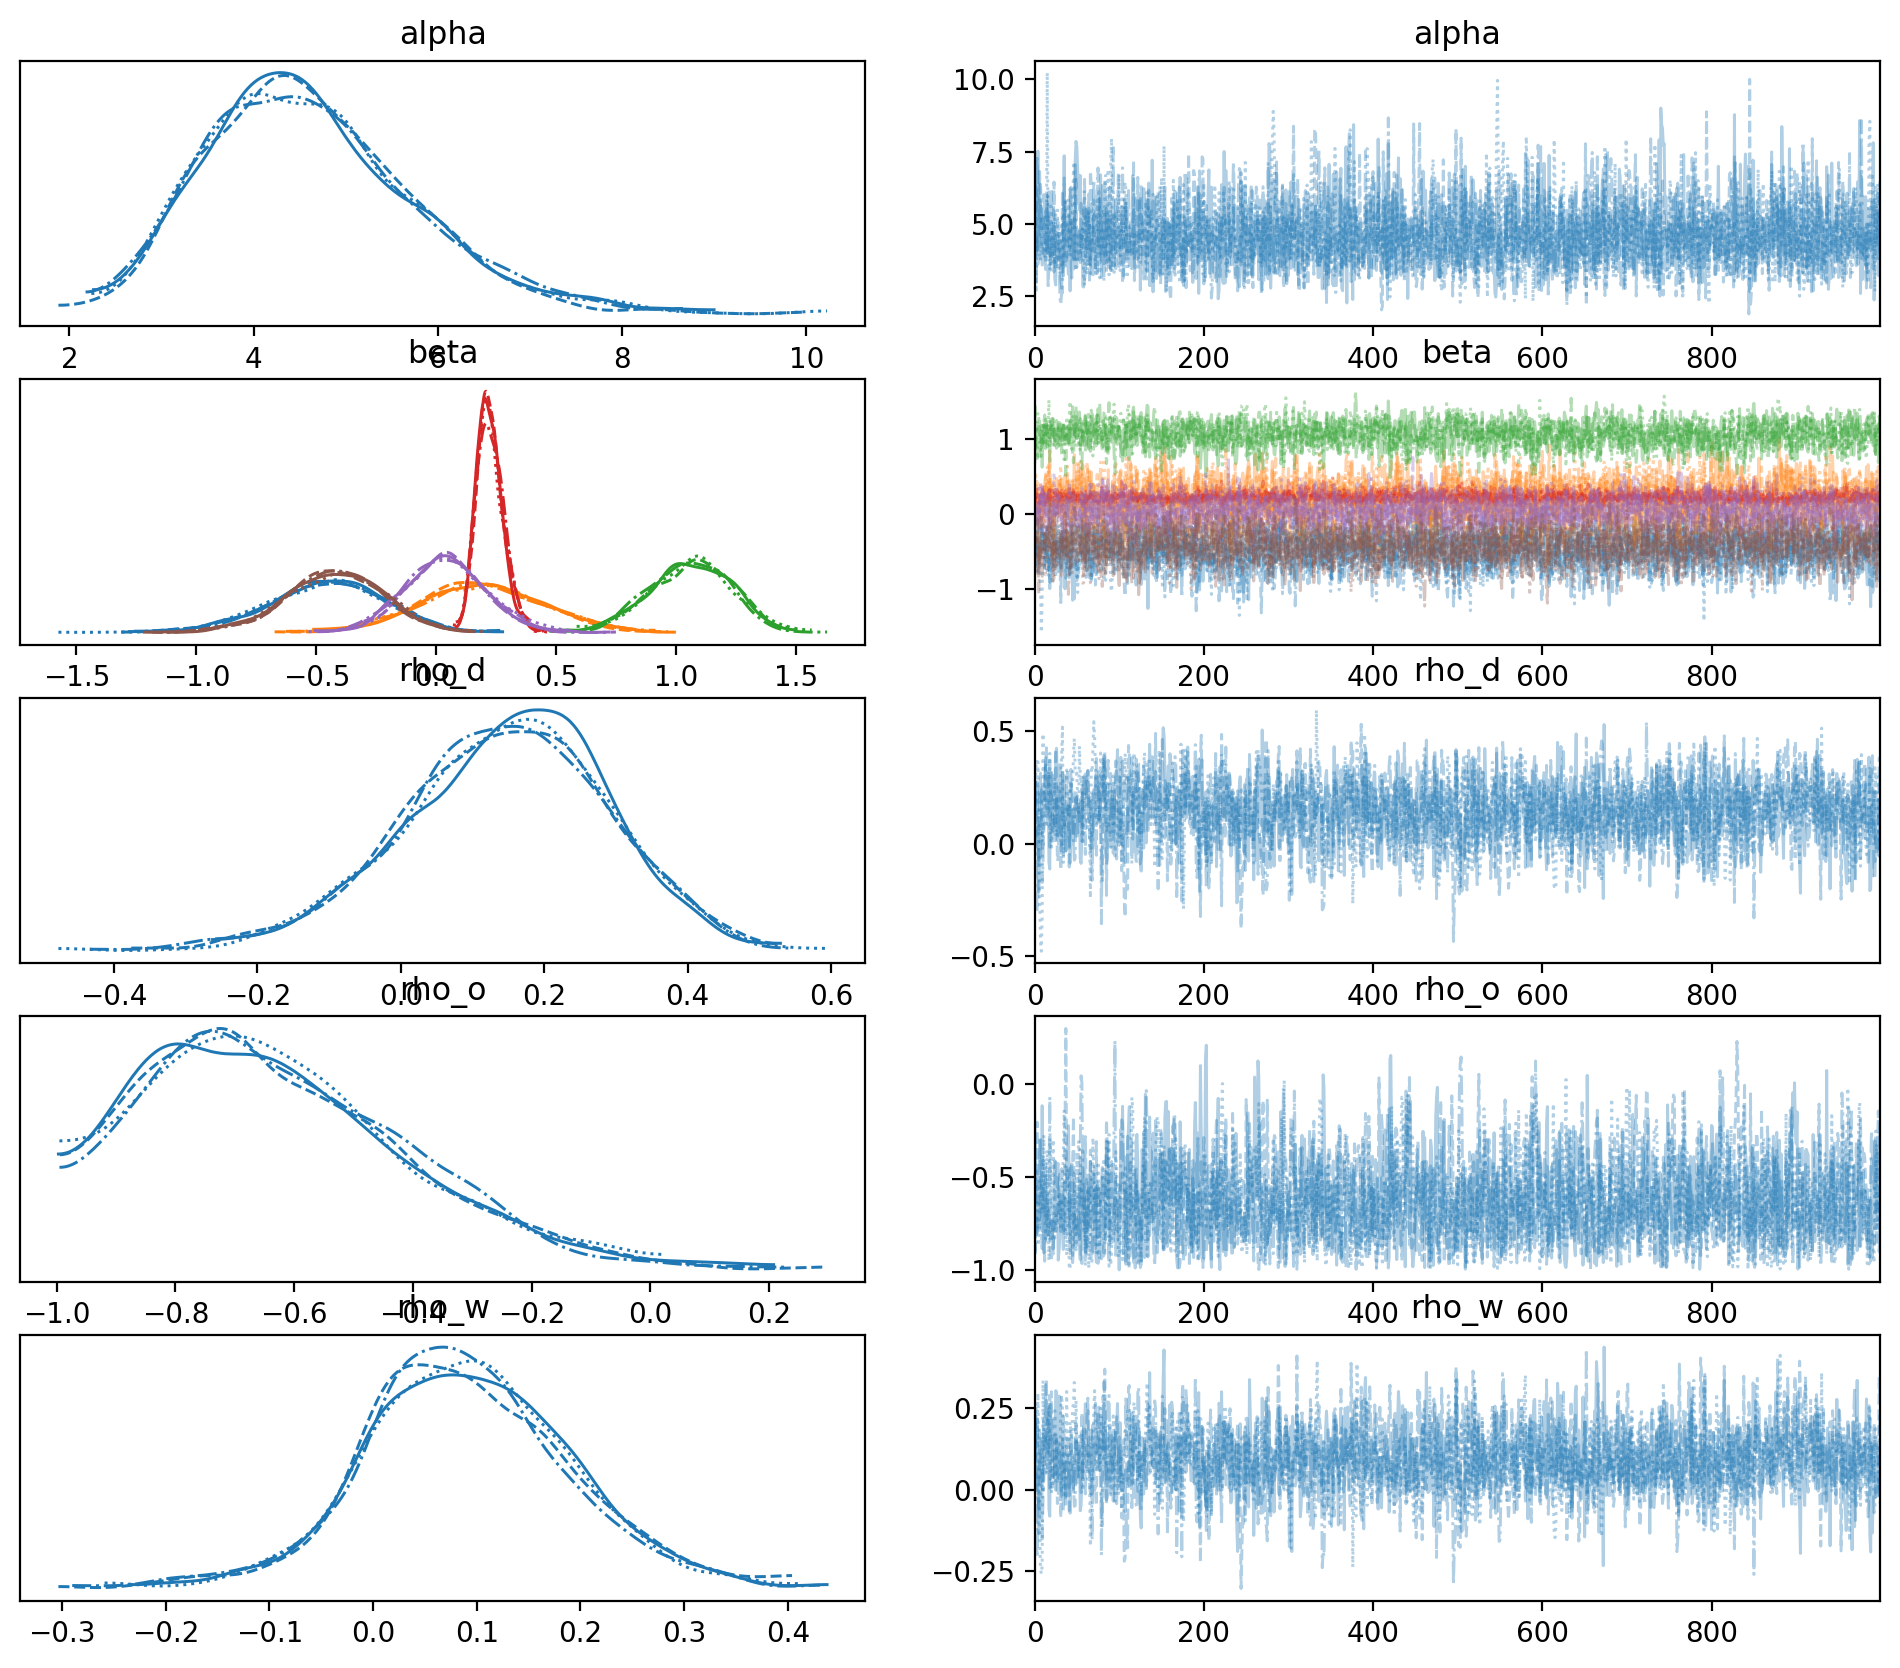

In [8]:
az.plot_trace(nb_sep_idata)